
────────────────────────────────────────────────────────────────────────────────
                             BOND ANALYTICS SUMMARY                             
────────────────────────────────────────────────────────────────────────────────
Bond                      Price    Δ Par     YTM   ModDur    Convex
────────────────────────────────────────────────────────────────────────────────
UK Gilt 2030           £1000.00    +0.00  5.000%   5.0757   32.4642  [PAR]
US Treasury 10Y        £ 852.80  -147.20  6.000%   7.8127   75.8864  [DISCOUNT]
Corporate Bond A       £1129.26  +129.26  5.000%   6.1861   49.1244  [PREMIUM]
EM Sovereign 15Y       £ 908.92   -91.08  7.000%   9.3877  120.4415  [DISCOUNT]
────────────────────────────────────────────────────────────────────────────────

── Rate Shock Analysis: US Treasury 10Y ──────────────────
  Shock -200bps │ Actual: +17.261%  Dur only: +15.625%  Dur+Conv: +17.143%  ▲
  Shock -100bps │ Actual: +8.206%  Dur only: +7.813%  Dur+Conv: +8.192%  ▲

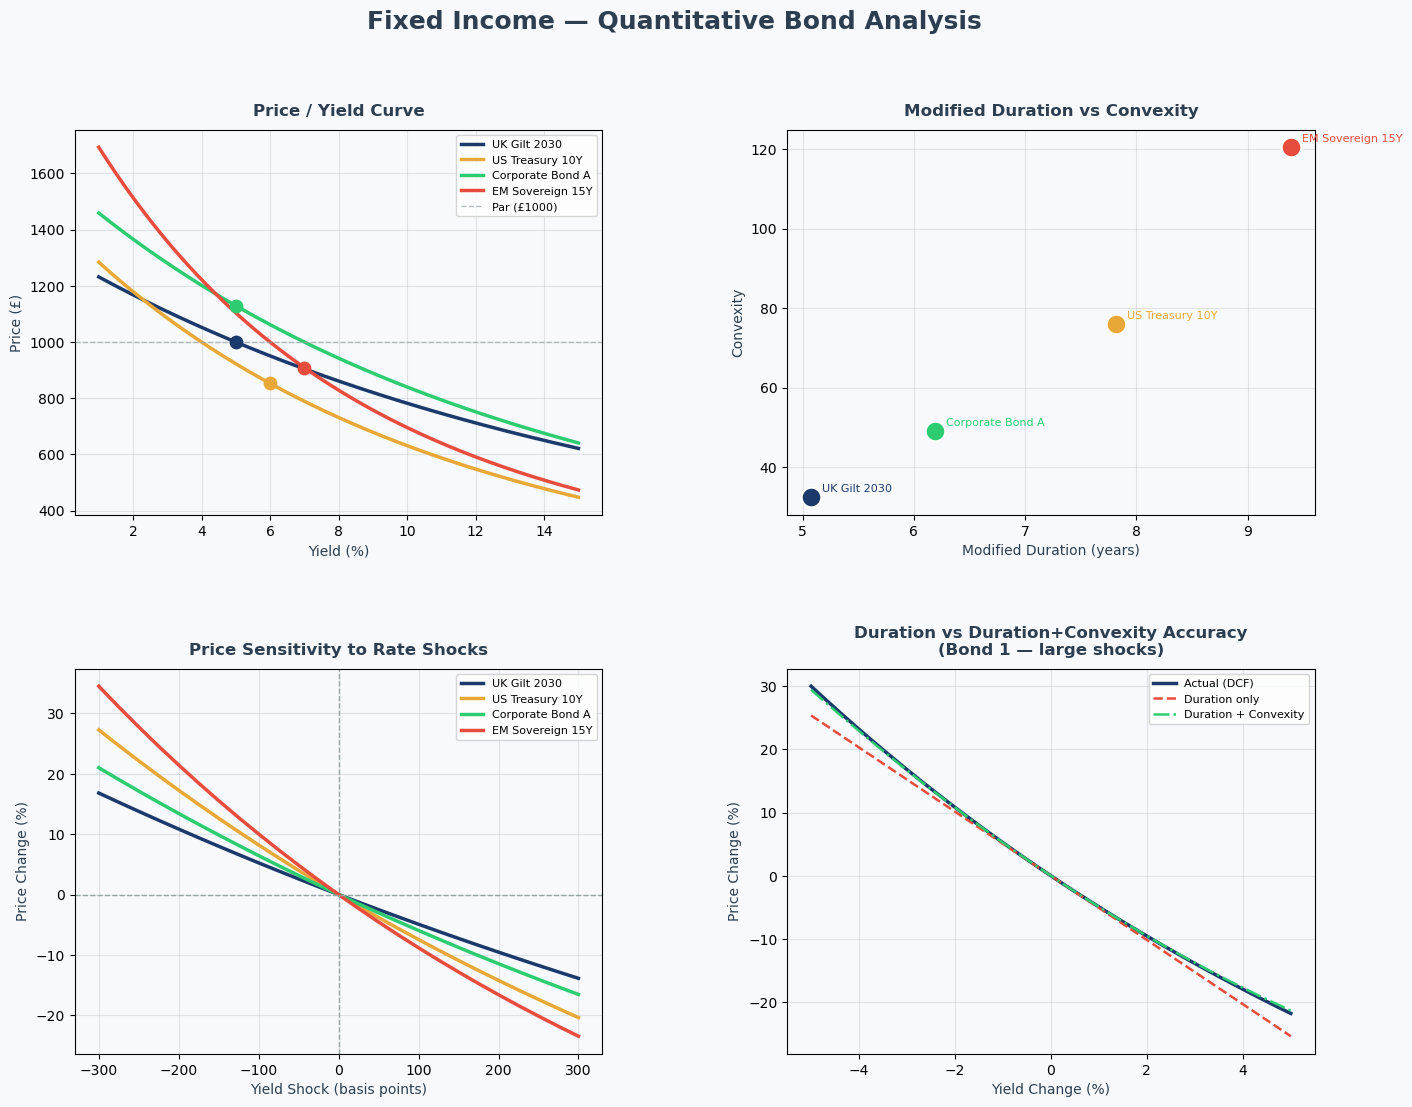


✅  Chart saved as 'bond_analysis.png'


In [1]:
"""
╔══════════════════════════════════════════════════════════════════╗
║           FIXED INCOME BOND ANALYSER                            ║
║           Quantitative Analysis Tool                            ║
║                                                                  ║
║  Features:                                                       ║
║    • Bond Pricing via Discounted Cash Flow (DCF)                ║
║    • Yield to Maturity (YTM) via Numerical Root Finding         ║
║    • Modified Duration & Convexity                              ║
║    • Price/Yield Curve Visualisation                            ║
║    • Interest Rate Shock Analysis                               ║
║    • Multi-Bond Portfolio Summary                               ║
╚══════════════════════════════════════════════════════════════════╝

Author  : [Adam Ansari]
Purpose : Fixed income quantitative analysis for bond pricing,
          risk measurement, and portfolio sensitivity.
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import brentq


# ─────────────────────────────────────────────
#  COLOUR PALETTE  (used across all charts)
# ─────────────────────────────────────────────
COLOURS = {
    "primary":    "#1B3A6B",   # deep navy
    "accent":     "#E8A838",   # gold
    "positive":   "#2ECC71",   # green
    "negative":   "#E74C3C",   # red
    "neutral":    "#95A5A6",   # grey
    "background": "#F7F9FC",   # off-white
    "text":       "#2C3E50",   # dark
}


# ══════════════════════════════════════════════
#  1. BOND PRICING  —  Discounted Cash Flow
# ══════════════════════════════════════════════

def price_bond(face_value: float, coupon_rate: float,
               yield_rate: float, years: int) -> float:
    """
    Price a bond using the Discounted Cash Flow (DCF) model.

    Each future coupon payment and the final face value are
    discounted back to today using the market yield as the
    discount rate.  The sum of all present values = bond price.

    Formula:
        P = Σ [ C / (1+y)^t ]  +  F / (1+y)^T

    Parameters
    ----------
    face_value  : par value of the bond (e.g. 1000)
    coupon_rate : annual coupon rate    (e.g. 0.05 = 5%)
    yield_rate  : market yield / discount rate
    years       : years remaining to maturity

    Returns
    -------
    float : fair price of the bond today
    """
    coupon = face_value * coupon_rate
    price  = sum(coupon / (1 + yield_rate) ** t for t in range(1, years + 1))
    price += face_value / (1 + yield_rate) ** years
    return round(price, 4)


# ══════════════════════════════════════════════
#  2. YIELD TO MATURITY  —  Numerical Root Finding
# ══════════════════════════════════════════════

def yield_to_maturity(face_value: float, coupon_rate: float,
                      market_price: float, years: int) -> float:
    """
    Solve for Yield to Maturity (YTM) given an observed market price.

    YTM cannot be isolated algebraically from the DCF formula because
    the yield 'y' appears in multiple terms with different exponents.
    Instead we use Brent's Method — a numerical root-finding algorithm
    that searches for the yield where:

        price_bond(y)  −  market_price  =  0

    This is a standard technique in quantitative finance.

    Parameters
    ----------
    face_value   : par value of the bond
    coupon_rate  : annual coupon rate
    market_price : current observed market price
    years        : years remaining to maturity

    Returns
    -------
    float : annualised yield to maturity
    """
    objective = lambda y: price_bond(face_value, coupon_rate, y, years) - market_price
    return round(brentq(objective, 1e-6, 0.9999), 6)


# ══════════════════════════════════════════════
#  3. DURATION  —  Price Sensitivity to Yield
# ══════════════════════════════════════════════

def macaulay_duration(face_value: float, coupon_rate: float,
                      yield_rate: float, years: int) -> float:
    """
    Calculate Macaulay Duration — the weighted average time
    (in years) to receive all cash flows, where each cash flow
    is weighted by its present value as a share of total price.

    Longer duration = cash flows received later on average.
    """
    coupon       = face_value * coupon_rate
    price        = price_bond(face_value, coupon_rate, yield_rate, years)
    weighted_sum = sum(t * (coupon / (1 + yield_rate) ** t) for t in range(1, years + 1))
    weighted_sum += years * (face_value / (1 + yield_rate) ** years)
    return round(weighted_sum / price, 4)


def modified_duration(face_value: float, coupon_rate: float,
                      yield_rate: float, years: int) -> float:
    """
    Calculate Modified Duration.

    Converts Macaulay Duration into a direct price sensitivity measure:

        Modified Duration ≈ % change in price for 1% change in yield

    A bond with Modified Duration of 7.5 will lose ~7.5% in price
    if market yields rise by 1%.  This is the primary risk metric
    used by fixed income traders.
    """
    mac_dur = macaulay_duration(face_value, coupon_rate, yield_rate, years)
    return round(mac_dur / (1 + yield_rate), 4)


# ══════════════════════════════════════════════
#  4. CONVEXITY  —  Curvature of Price/Yield Relationship
# ══════════════════════════════════════════════

def convexity(face_value: float, coupon_rate: float,
              yield_rate: float, years: int) -> float:
    """
    Calculate Convexity — the second-order price sensitivity.

    Duration assumes a linear price/yield relationship, but in
    reality the curve is convex (bowed outward).  Convexity
    captures this curvature and improves price change estimates.

    Key insight: convexity is always POSITIVE for standard bonds,
    meaning bonds gain MORE when yields fall than they lose when
    yields rise by the same amount.  This asymmetry is valuable.

    Used in the full price change approximation:
        ΔP/P ≈ −ModDur × Δy  +  ½ × Convexity × (Δy)²
    """
    coupon    = face_value * coupon_rate
    price     = price_bond(face_value, coupon_rate, yield_rate, years)
    conv_sum  = sum(t * (t + 1) * (coupon / (1 + yield_rate) ** t)
                    for t in range(1, years + 1))
    conv_sum += years * (years + 1) * (face_value / (1 + yield_rate) ** years)
    return round(conv_sum / (price * (1 + yield_rate) ** 2), 4)


# ══════════════════════════════════════════════
#  5. PRICE CHANGE ESTIMATE  —  Duration + Convexity
# ══════════════════════════════════════════════

def estimate_price_change(face_value: float, coupon_rate: float,
                          yield_rate: float, years: int,
                          yield_shock: float) -> dict:
    """
    Estimate the % price change for a given yield shock using
    both Duration and Convexity (the full second-order approximation).

    Returns a breakdown showing:
      - Duration-only estimate  (linear approximation)
      - Convexity adjustment    (curvature correction)
      - Combined estimate       (more accurate)
      - Actual price change     (exact, from DCF repricing)
    """
    md  = modified_duration(face_value, coupon_rate, yield_rate, years)
    cx  = convexity(face_value, coupon_rate, yield_rate, years)

    duration_effect  = -md * yield_shock * 100
    convexity_effect =  0.5 * cx * yield_shock ** 2 * 100
    combined         = duration_effect + convexity_effect

    # exact repricing for comparison
    original_price = price_bond(face_value, coupon_rate, yield_rate, years)
    shocked_price  = price_bond(face_value, coupon_rate,
                                yield_rate + yield_shock, years)
    actual_change  = ((shocked_price - original_price) / original_price) * 100

    return {
        "duration_effect_pct":  round(duration_effect,  4),
        "convexity_effect_pct": round(convexity_effect, 4),
        "combined_estimate_pct":round(combined,          4),
        "actual_change_pct":    round(actual_change,     4),
        "original_price":       original_price,
        "shocked_price":        shocked_price,
    }


# ══════════════════════════════════════════════
#  6. BOND SUMMARY  —  Full Analytics Report
# ══════════════════════════════════════════════

def bond_summary(name: str, face_value: float, coupon_rate: float,
                 yield_rate: float, years: int) -> dict:
    """Return a full analytics dictionary for a single bond."""
    price = price_bond(face_value, coupon_rate, yield_rate, years)
    return {
        "name":              name,
        "face_value":        face_value,
        "coupon_rate":       coupon_rate,
        "yield_rate":        yield_rate,
        "years":             years,
        "price":             price,
        "premium_discount":  round(price - face_value, 2),
        "mac_duration":      macaulay_duration(face_value, coupon_rate, yield_rate, years),
        "mod_duration":      modified_duration(face_value, coupon_rate, yield_rate, years),
        "convexity":         convexity(face_value, coupon_rate, yield_rate, years),
        "ytm":               yield_to_maturity(face_value, coupon_rate, price, years),
    }


# ══════════════════════════════════════════════
#  7. VISUALISATION
# ══════════════════════════════════════════════

def plot_analysis(bonds: list[dict]) -> None:
    """
    Generate a 4-panel quantitative analysis dashboard:

      Panel 1 — Price / Yield curves for all bonds
      Panel 2 — Duration vs Convexity scatter
      Panel 3 — Interest rate shock analysis (±300bps)
      Panel 4 — Duration vs Convexity approximation accuracy
    """

    fig = plt.figure(figsize=(16, 12), facecolor=COLOURS["background"])
    fig.suptitle("Fixed Income — Quantitative Bond Analysis",
                 fontsize=18, fontweight="bold",
                 color=COLOURS["text"], y=0.98)

    gs     = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)
    ax1    = fig.add_subplot(gs[0, 0])
    ax2    = fig.add_subplot(gs[0, 1])
    ax3    = fig.add_subplot(gs[1, 0])
    ax4    = fig.add_subplot(gs[1, 1])

    palette = [COLOURS["primary"], COLOURS["accent"],
               COLOURS["positive"], COLOURS["negative"]]

    yields_range = np.linspace(0.01, 0.15, 300)

    # ── Panel 1: Price / Yield Curves ──────────────────────────
    ax1.set_facecolor(COLOURS["background"])
    ax1.set_title("Price / Yield Curve", fontweight="bold",
                  color=COLOURS["text"], pad=10)

    for i, bond in enumerate(bonds):
        prices = [price_bond(bond["face_value"], bond["coupon_rate"], y,
                             bond["years"]) for y in yields_range]
        ax1.plot(yields_range * 100, prices,
                 color=palette[i % len(palette)],
                 linewidth=2.5, label=bond["name"])
        # mark current yield/price point
        ax1.scatter(bond["yield_rate"] * 100, bond["price"],
                    color=palette[i % len(palette)], s=80, zorder=5)

    ax1.axhline(y=1000, color=COLOURS["neutral"], linestyle="--",
                linewidth=1, alpha=0.7, label="Par (£1000)")
    ax1.set_xlabel("Yield (%)", color=COLOURS["text"])
    ax1.set_ylabel("Price (£)", color=COLOURS["text"])
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)

    # ── Panel 2: Duration vs Convexity ─────────────────────────
    ax2.set_facecolor(COLOURS["background"])
    ax2.set_title("Modified Duration vs Convexity",
                  fontweight="bold", color=COLOURS["text"], pad=10)

    for i, bond in enumerate(bonds):
        ax2.scatter(bond["mod_duration"], bond["convexity"],
                    color=palette[i % len(palette)],
                    s=200, zorder=5, edgecolors="white", linewidth=1.5)
        ax2.annotate(bond["name"],
                     (bond["mod_duration"], bond["convexity"]),
                     textcoords="offset points", xytext=(8, 4),
                     fontsize=8, color=palette[i % len(palette)])

    ax2.set_xlabel("Modified Duration (years)", color=COLOURS["text"])
    ax2.set_ylabel("Convexity", color=COLOURS["text"])
    ax2.grid(True, alpha=0.3)

    # ── Panel 3: Rate Shock Sensitivity ────────────────────────
    ax3.set_facecolor(COLOURS["background"])
    ax3.set_title("Price Sensitivity to Rate Shocks",
                  fontweight="bold", color=COLOURS["text"], pad=10)

    shocks_bps = np.arange(-300, 325, 25)

    for i, bond in enumerate(bonds):
        original = bond["price"]
        pct_changes = [
            ((price_bond(bond["face_value"], bond["coupon_rate"],
                         bond["yield_rate"] + s / 10000,
                         bond["years"]) - original) / original) * 100
            for s in shocks_bps
        ]
        ax3.plot(shocks_bps, pct_changes,
                 color=palette[i % len(palette)],
                 linewidth=2.5, label=bond["name"])

    ax3.axhline(0, color=COLOURS["neutral"], linewidth=1, linestyle="--")
    ax3.axvline(0, color=COLOURS["neutral"], linewidth=1, linestyle="--")
    ax3.set_xlabel("Yield Shock (basis points)", color=COLOURS["text"])
    ax3.set_ylabel("Price Change (%)", color=COLOURS["text"])
    ax3.legend(fontsize=8)
    ax3.grid(True, alpha=0.3)

    # ── Panel 4: Duration vs Convexity Approximation Accuracy ──
    ax4.set_facecolor(COLOURS["background"])
    ax4.set_title("Duration vs Duration+Convexity Accuracy\n(Bond 1 — large shocks)",
                  fontweight="bold", color=COLOURS["text"], pad=10)

    bond = bonds[0]
    md   = bond["mod_duration"]
    cx   = bond["convexity"]
    original = bond["price"]

    shock_range = np.linspace(-0.05, 0.05, 200)

    actual_changes   = [((price_bond(bond["face_value"], bond["coupon_rate"],
                                     bond["yield_rate"] + s,
                                     bond["years"]) - original) / original) * 100
                        for s in shock_range]

    duration_only    = [-md * s * 100 for s in shock_range]
    dur_plus_convex  = [(-md * s + 0.5 * cx * s ** 2) * 100 for s in shock_range]

    ax4.plot(shock_range * 100, actual_changes,
             color=COLOURS["primary"], linewidth=2.5, label="Actual (DCF)")
    ax4.plot(shock_range * 100, duration_only,
             color=COLOURS["negative"], linewidth=1.8,
             linestyle="--", label="Duration only")
    ax4.plot(shock_range * 100, dur_plus_convex,
             color=COLOURS["positive"], linewidth=1.8,
             linestyle="-.", label="Duration + Convexity")

    ax4.set_xlabel("Yield Change (%)", color=COLOURS["text"])
    ax4.set_ylabel("Price Change (%)", color=COLOURS["text"])
    ax4.legend(fontsize=8)
    ax4.grid(True, alpha=0.3)

    plt.savefig("bond_analysis.png", dpi=150, bbox_inches="tight",
                facecolor=COLOURS["background"])
    plt.show()
    print("\n✅  Chart saved as 'bond_analysis.png'")


# ══════════════════════════════════════════════
#  8. PORTFOLIO PRINTER
# ══════════════════════════════════════════════

def print_portfolio(bonds: list[dict]) -> None:
    """Print a formatted analytics table for a list of bonds."""

    header = (f"\n{'─'*80}\n"
              f"{'BOND ANALYTICS SUMMARY':^80}\n"
              f"{'─'*80}\n"
              f"{'Bond':<22} {'Price':>8} {'Δ Par':>8} "
              f"{'YTM':>7} {'ModDur':>8} {'Convex':>9}\n"
              f"{'─'*80}")
    print(header)

    for b in bonds:
        delta  = f"+{b['premium_discount']:.2f}" if b['premium_discount'] >= 0 \
                 else f"{b['premium_discount']:.2f}"
        status = "PREMIUM" if b["premium_discount"] > 0.01 \
                 else "DISCOUNT" if b["premium_discount"] < -0.01 else "PAR"

        print(f"{b['name']:<22} "
              f"£{b['price']:>7.2f} "
              f"{delta:>8} "
              f"{b['ytm']*100:>6.3f}% "
              f"{b['mod_duration']:>8.4f} "
              f"{b['convexity']:>9.4f}  "
              f"[{status}]")

    print(f"{'─'*80}")


# ══════════════════════════════════════════════
#  MAIN  —  Run the full analysis
# ══════════════════════════════════════════════

if __name__ == "__main__":

    # ── Define a portfolio of bonds ────────────────────────────
    # Each bond: name, face_value, coupon_rate, yield_rate, years
    portfolio_params = [
        ("UK Gilt 2030",       1000, 0.05, 0.05, 6),    # at par
        ("US Treasury 10Y",    1000, 0.04, 0.06, 10),   # discount
        ("Corporate Bond A",   1000, 0.07, 0.05, 8),    # premium
        ("EM Sovereign 15Y",   1000, 0.06, 0.07, 15),   # long duration
    ]

    # ── Build full analytics for each bond ─────────────────────
    portfolio = [bond_summary(*p) for p in portfolio_params]

    # ── Print portfolio table ───────────────────────────────────
    print_portfolio(portfolio)

    # ── Rate shock deep-dive on one bond ───────────────────────
    print("\n── Rate Shock Analysis: US Treasury 10Y ──────────────────")
    for shock_bps in [-200, -100, -50, +50, +100, +200]:
        result = estimate_price_change(
            face_value  = 1000,
            coupon_rate = 0.04,
            yield_rate  = 0.06,
            years       = 10,
            yield_shock = shock_bps / 10000
        )
        direction = "▲" if result["actual_change_pct"] > 0 else "▼"
        print(f"  Shock {shock_bps:+4d}bps │ "
              f"Actual: {result['actual_change_pct']:+6.3f}%  "
              f"Dur only: {result['duration_effect_pct']:+6.3f}%  "
              f"Dur+Conv: {result['combined_estimate_pct']:+6.3f}%  {direction}")

    # ── Plot the full dashboard ─────────────────────────────────
    print("\n── Generating charts... ───────────────────────────────────")
    plot_analysis(portfolio)